# Python 位运算简洁总结

本文用 Python 代码总结常见位运算：

- 与运算 `&`
- 或运算 `|`
- 异或运算 `^`
- 取反运算 `~`
- 左移 `<<`
- 右移 `>>`
- 常见位运算技巧

注意：Python 的整数不是固定 8 位，而是任意精度整数。  
因此如果想观察 **8-bit 补码效果**，需要手动用 `& 0xff` 截断到 8 位。

## 1. 辅助函数：显示 8-bit 二进制

Python 中可以用 `format(x, "08b")` 显示 8 位二进制。

对于负数，如果想看它的 8-bit 补码形式，可以先做：

```python
x & 0xff
```

这里 `0xff` 等价于二进制：

```text
11111111
```

In [ ]:
def bin8(x):
    """Return the 8-bit binary representation of integer x."""
    return format(x & 0xff, "08b")

# for negative numbers, the bitwise AND with 0xff will give the correct 8-bit two's complement representation.
for x in [46, 51, -47, -52, -50]:
    print(f"{x:4d} -> {bin8(x)}")

  46 -> 00101110
  51 -> 00110011
 -47 -> 11010001
 -52 -> 11001100
 -50 -> 11001110


## 2. 与运算 `&`

规则：

```text
只有两个对应二进制位都是 1，结果才是 1
```

例如：

```text
46 = 00101110
51 = 00110011
```

In [2]:
a = 46
b = 51

result = a & b

print("a       =", bin8(a), a)
print("b       =", bin8(b), b)
print("a & b   =", bin8(result), result)

a       = 00101110 46
b       = 00110011 51
a & b   = 00100010 34


## 3. 或运算 `|`

规则：

```text
只要两个对应二进制位至少有一个是 1，结果就是 1
```

In [3]:
a = 46
b = 51

result = a | b

print("a       =", bin8(a), a)
print("b       =", bin8(b), b)
print("a | b   =", bin8(result), result)

a       = 00101110 46
b       = 00110011 51
a | b   = 00111111 63


## 4. 异或运算 `^`

规则：

```text
相同为 0，不同为 1
```

异或常用性质：

```text
a ^ a = 0
a ^ 0 = a
```

In [4]:
a = 46
b = 51

result = a ^ b

print("a       =", bin8(a), a)
print("b       =", bin8(b), b)
print("a ^ b   =", bin8(result), result)

print()
print("a ^ a =", a ^ a)
print("a ^ 0 =", a ^ 0)

a       = 00101110 46
b       = 00110011 51
a ^ b   = 00011101 29

a ^ a = 0
a ^ 0 = 46


## 5. 取反运算 `~`

规则：

```text
每一位取反：0 变 1，1 变 0
```

在补码系统中：

```text
~x = -x - 1
```

所以：

```text
~46 = -47
~51 = -52
```

In [5]:
for x in [46, 51]:
    y = ~x
    print(f"x      = {x:4d}, bin8(x)  = {bin8(x)}")
    print(f"~x     = {y:4d}, bin8(~x) = {bin8(y)}")
    print(f"-x - 1 = {-x - 1}")
    print()

x      =   46, bin8(x)  = 00101110
~x     =  -47, bin8(~x) = 11010001
-x - 1 = -47

x      =   51, bin8(x)  = 00110011
~x     =  -52, bin8(~x) = 11001100
-x - 1 = -52



## 6. 左移运算 `<<`

规则：

```text
所有二进制位向左移动，低位补 0
```

数学上通常对应：

```text
a << k = a * 2^k
```

但是如果在固定 bit 数下，左移可能溢出。

In [6]:
x = 29

print("x        =", bin8(x), x)
print("x << 2   =", bin8(x << 2), x << 2)
print("x * 4    =", x * 4)

print()
print("如果只看 8-bit 结果：")
y = (x << 3) & 0xff
print("x << 3, 8-bit binary =", bin8(y))

# Interpret y as signed 8-bit integer
signed_y = y if y < 128 else y - 256
print("as signed 8-bit integer =", signed_y)

x        = 00011101 29
x << 2   = 01110100 116
x * 4    = 116

如果只看 8-bit 结果：
x << 3, 8-bit binary = 11101000
as signed 8-bit integer = -24


## 7. 右移运算 `>>`

Python 的 `>>` 对负数使用的是 **算术右移**。

算术右移的特点：

```text
高位补符号位
```

因此负数右移后仍然是负数。

In [7]:
x = 50

print("x      =", bin8(x), x)
print("x >> 1 =", bin8(x >> 1), x >> 1)
print("x >> 2 =", bin8(x >> 2), x >> 2)

x      = 00110010 50
x >> 1 = 00011001 25
x >> 2 = 00001100 12


## 8. 负数的算术右移

例如：

```text
-50 的 8-bit 补码是 11001110
```

Python 中：

```python
-50 >> 2
```

得到 `-13`，这是算术右移。

In [8]:
x = -50

print("x      =", bin8(x), x)
print("x >> 2 =", bin8(x >> 2), x >> 2)

x      = 11001110 -50
x >> 2 = 11110011 -13


## 9. 模拟 8-bit 逻辑右移

Python 没有单独的逻辑右移运算符。  
如果想模拟 8-bit 逻辑右移，可以先用 `& 0xff` 把数限制到 8 位，再右移。

例如：

```text
-50 = 11001110
逻辑右移 2 位 = 00110011 = 51
```

In [9]:
x = -50

logical_shift = (x & 0xff) >> 2

print("x as 8-bit        =", bin8(x))
print("logical x >>> 2   =", bin8(logical_shift), logical_shift)

x as 8-bit        = 11001110
logical x >>> 2   = 00110011 51


## 10. 右移和整数除法的区别

对于非负数：

```text
x >> k 近似等价于 x // 2^k
```

对于负数要小心。

Python 中：

```python
-50 >> 2
```

等价于向下取整，所以结果是 `-13`。

而很多语言中的整数除法可能向 0 取整，结果可能是 `-12`。

In [10]:
x = -50

print("x >> 2      =", x >> 2)
print("x // 4      =", x // 4)
print("int(x / 4)  =", int(x / 4))

print()
print("说明：")
print("x // 4 是向下取整")
print("int(x / 4) 是向 0 取整")

x >> 2      = -13
x // 4      = -13
int(x / 4)  = -12

说明：
x // 4 是向下取整
int(x / 4) 是向 0 取整


## 11. 常见性质验证

几个常见公式：

```text
a & a = a
a | a = a
a ^ a = 0
a ^ 0 = a
a & 0 = 0
a | 0 = a
```

In [11]:
a = 13

print("a       =", bin8(a), a)
print("a & a   =", a & a)
print("a | a   =", a | a)
print("a ^ a   =", a ^ a)
print("a ^ 0   =", a ^ 0)
print("a & 0   =", a & 0)
print("a | 0   =", a | 0)

a       = 00001101 13
a & a   = 13
a | a   = 13
a ^ a   = 0
a ^ 0   = 13
a & 0   = 0
a | 0   = 13


## 12. 技巧一：`a & (a - 1)`

作用：

```text
把 a 的二进制表示中最低位的 1 变成 0
```

例如：

```text
12 = 1100
11 = 1011
12 & 11 = 1000
```

这个技巧常用于统计二进制中 `1` 的个数。

In [12]:
a = 12

print("a       =", bin8(a), a)
print("a - 1   =", bin8(a - 1), a - 1)
print("a & (a - 1) =", bin8(a & (a - 1)), a & (a - 1))

a       = 00001100 12
a - 1   = 00001011 11
a & (a - 1) = 00001000 8


In [13]:
def count_ones(x):
    count = 0
    while x:
        x = x & (x - 1)
        count += 1
    return count


for x in [7, 8, 12, 15, 46]:
    print(f"{x:2d} = {bin8(x)}, number of ones = {count_ones(x)}")

 7 = 00000111, number of ones = 3
 8 = 00001000, number of ones = 1
12 = 00001100, number of ones = 2
15 = 00001111, number of ones = 4
46 = 00101110, number of ones = 4


## 13. 技巧二：`a & (-a)`

作用：

```text
只保留 a 的二进制表示中最低位的 1
```

例如：

```text
12 = 1100
12 & (-12) = 0100
```

In [14]:
a = 12

lowbit = a & (-a)

print("a        =", bin8(a), a)
print("-a       =", bin8(-a), -a)
print("a & (-a) =", bin8(lowbit), lowbit)

a        = 00001100 12
-a       = 11110100 -12
a & (-a) = 00000100 4


In [15]:
for x in [6, 8, 10, 12, 40]:
    print(f"{x:2d} = {bin8(x)}, lowbit = {x & -x}")

 6 = 00000110, lowbit = 2
 8 = 00001000, lowbit = 8
10 = 00001010, lowbit = 2
12 = 00001100, lowbit = 4
40 = 00101000, lowbit = 8


## 14. 总结

Python 中常见位运算：

```text
&   与运算
|   或运算
^   异或运算
~   取反运算
<<  左移
>>  算术右移
```

常用公式：

```text
~x = -x - 1
-x = ~x + 1
a & (a - 1)：去掉最低位的 1
a & (-a)：只保留最低位的 1
a ^ a = 0
a ^ 0 = a
```

需要注意：

```text
Python 的整数不是固定 8 位
如果要观察 8-bit 补码，需要使用 x & 0xff
Python 的 >> 是算术右移
Python 没有单独的 >>> 逻辑右移运算符
```

# Application


## Reverse Bits

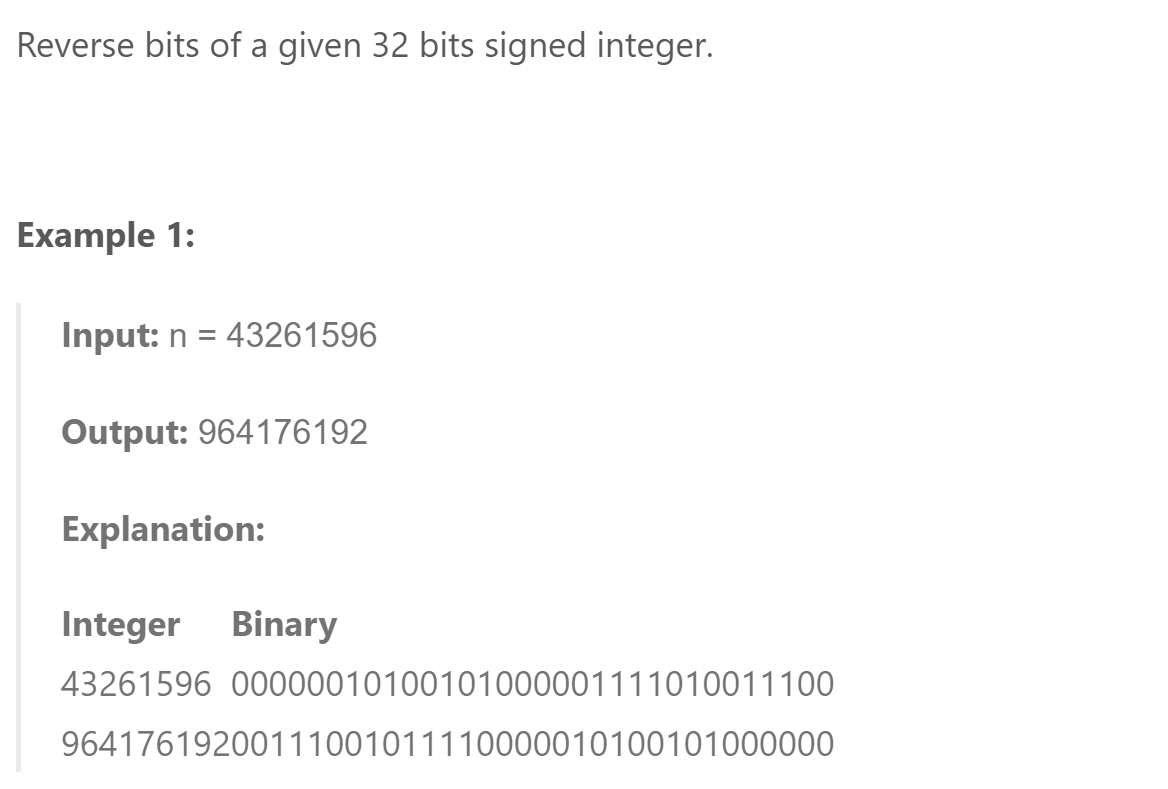

```python
class Solution(object):
    def reverseBits(self, n):
        """
        :type n: int
        :rtype: int
        """
        res = 0
        
        for _ in range(32):
            res <<= 1
            res |= (n & 1)
            n >>= 1
            
        return res
```

# Single Number
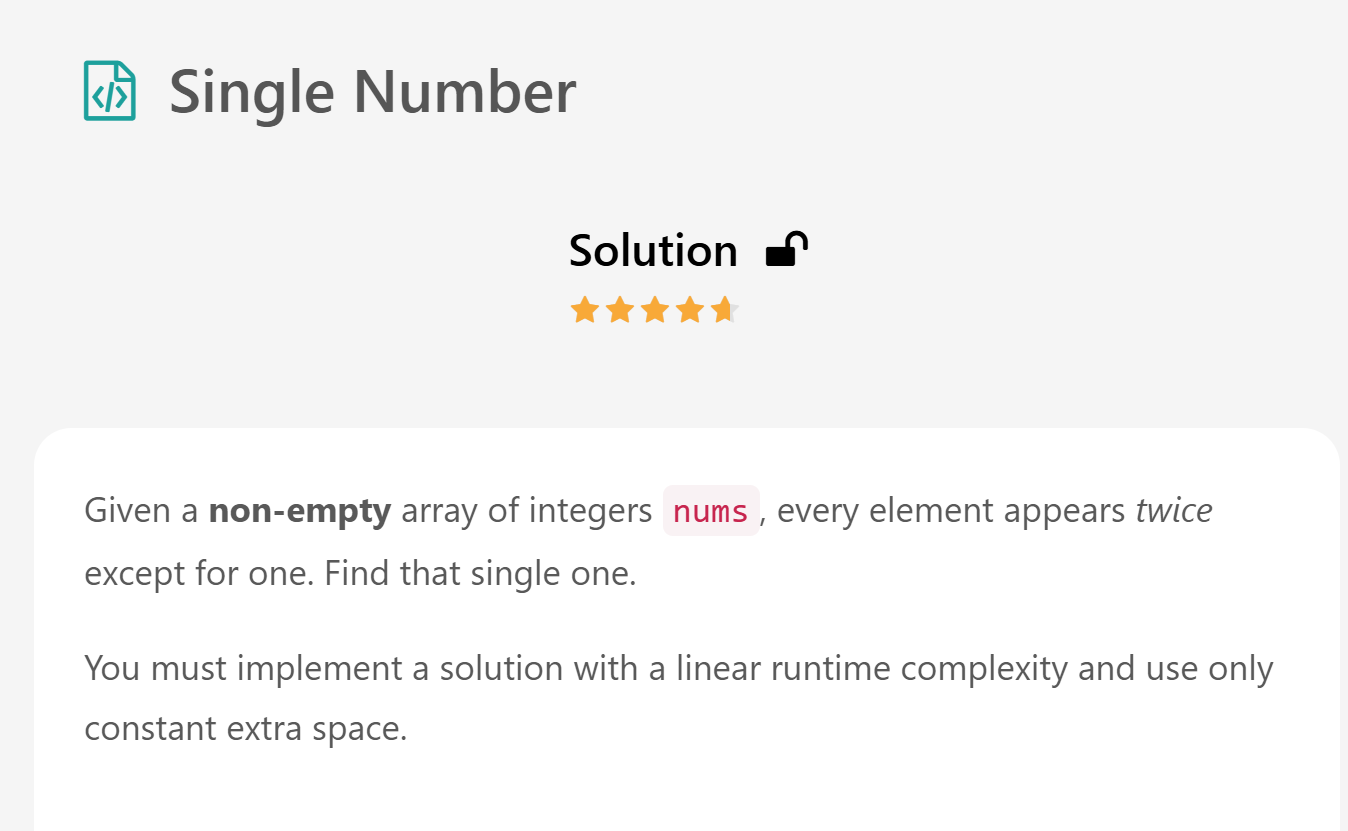

```python
class Solution(object):
    def singleNumber(self, nums):
        """
        :type nums: List[int]
        :rtype: int
        """
        res = 0
        for n in nums:
            res ^= n
        
        return res
``` 

## Single Number II
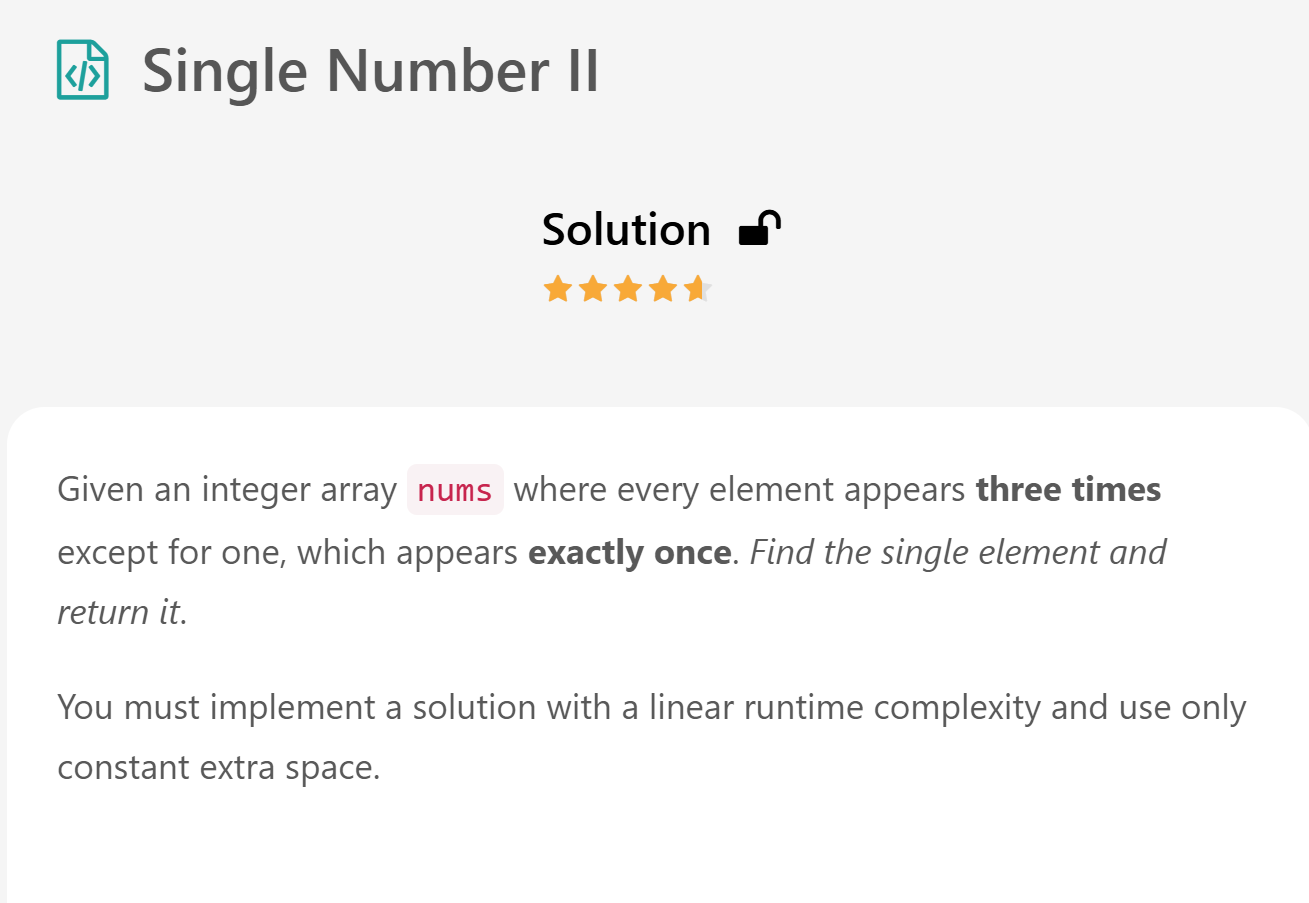

```python
class Solution(object):
    def singleNumber(self, nums):
        """
        :type nums: List[int]
        :rtype: int
        """
        ones = 0
        twos = 0

        for n in nums:
            ones = (ones ^ n) & ~twos
            twos = (twos ^ n) & ~ones

        return ones
        
```